In [6]:
# TASKS BASED ON NEW YORK CITY AIRBNB DATASET (Task 1:Using Data Cleaning (Missing Values, Price Outliers, Duplicate Listings))

import pandas as pd

# Load Dataset
df = pd.read_csv(r"C:\Users\Alana\Downloads\AB_NYC_2019.csv .zip")

# Remove extra spaces from column names
df.columns = df.columns.str.strip()

# Check missing values
print("Missing Values")
print(df.isnull().sum())

# Fill missing values
df["name"] = df["name"].fillna("Unknown")
df["host_name"] = df["host_name"].fillna("Unknown")
df["reviews_per_month"] = df["reviews_per_month"].fillna(df["reviews_per_month"].median())

# Remove duplicate listings
print("Duplicate Rows Before:", df.duplicated().sum())
df = df.drop_duplicates()
print("Duplicate Rows After:", df.duplicated().sum())

# Remove price outliers using IQR
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df["price"] >= lower) &
        (df["price"] <= upper)]

print(df.info())

# Save cleaned dataset
df.to_csv("airbnb_clean.csv", index=False)

Missing Values
id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64
Duplicate Rows Before: 0
Duplicate Rows After: 0
<class 'pandas.core.frame.DataFrame'>
Index: 45923 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              45923 non-null  int6

In [7]:
# TASKS BASED ON NEW YORK CITY AIRBNB DATASET (Task 2:Using Data Analysis )

import pandas as pd

# Load cleaned dataset
df = pd.read_csv(r"C:\Users\Alana\Downloads\AB_NYC_2019.csv .zip")

# Most Expensive Neighbourhoods
print("Most Expensive Neighbourhoods")
print(df.groupby("neighbourhood_group")["price"].mean().sort_values(ascending=False))

# Room Type Comparison
print("\nRoom Type Comparison")
print(df.groupby("room_type")["price"].mean())

# Availability Analysis
print("\nAvailability Analysis")
print(df["availability_365"].describe())

# Reviews vs Pricing
print("\nReviews vs Price Correlation")
print(df[["number_of_reviews","price"]].corr())

Most Expensive Neighbourhoods
neighbourhood_group
Manhattan        196.875814
Brooklyn         124.383207
Staten Island    114.812332
Queens            99.517649
Bronx             87.496792
Name: price, dtype: float64

Room Type Comparison
room_type
Entire home/apt    211.794246
Private room        89.780973
Shared room         70.127586
Name: price, dtype: float64

Availability Analysis
count    48895.000000
mean       112.781327
std        131.622289
min          0.000000
25%          0.000000
50%         45.000000
75%        227.000000
max        365.000000
Name: availability_365, dtype: float64

Reviews vs Price Correlation
                   number_of_reviews     price
number_of_reviews           1.000000 -0.047954
price                      -0.047954  1.000000


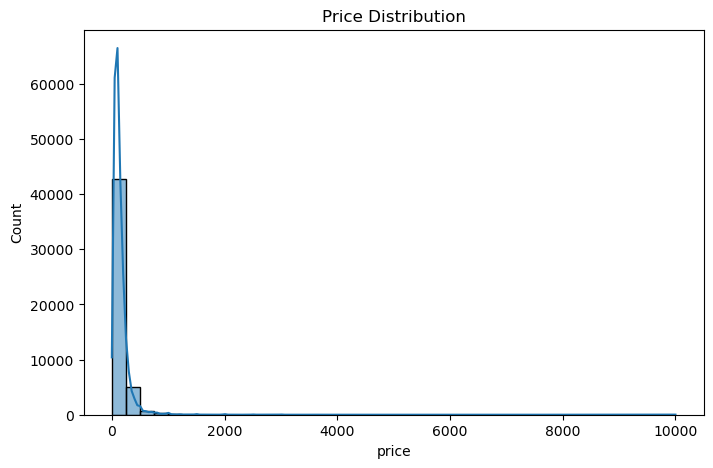

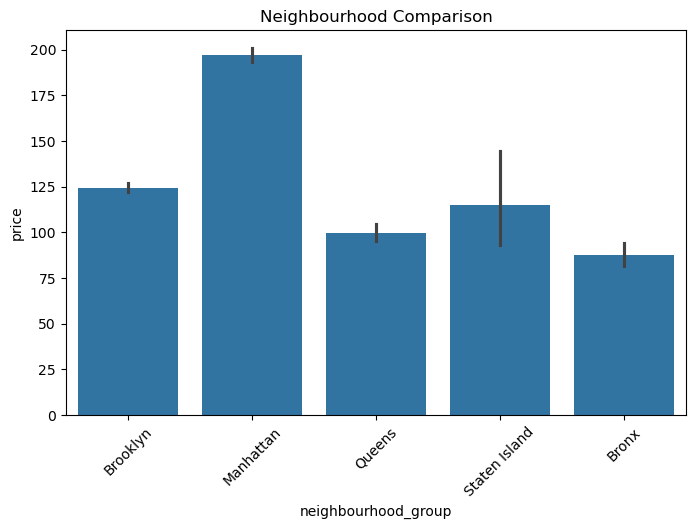

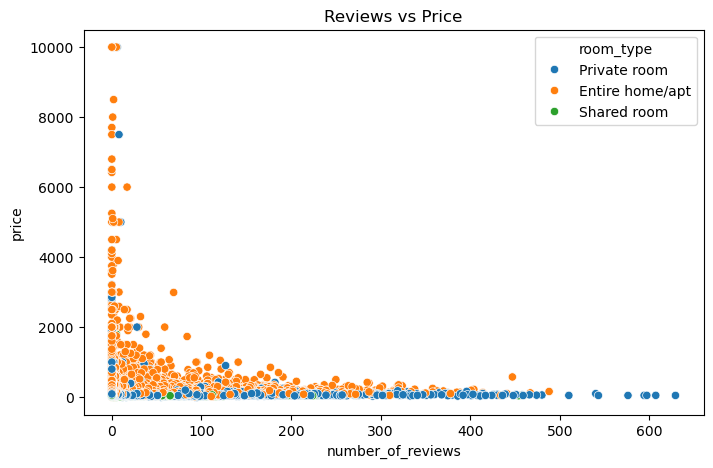

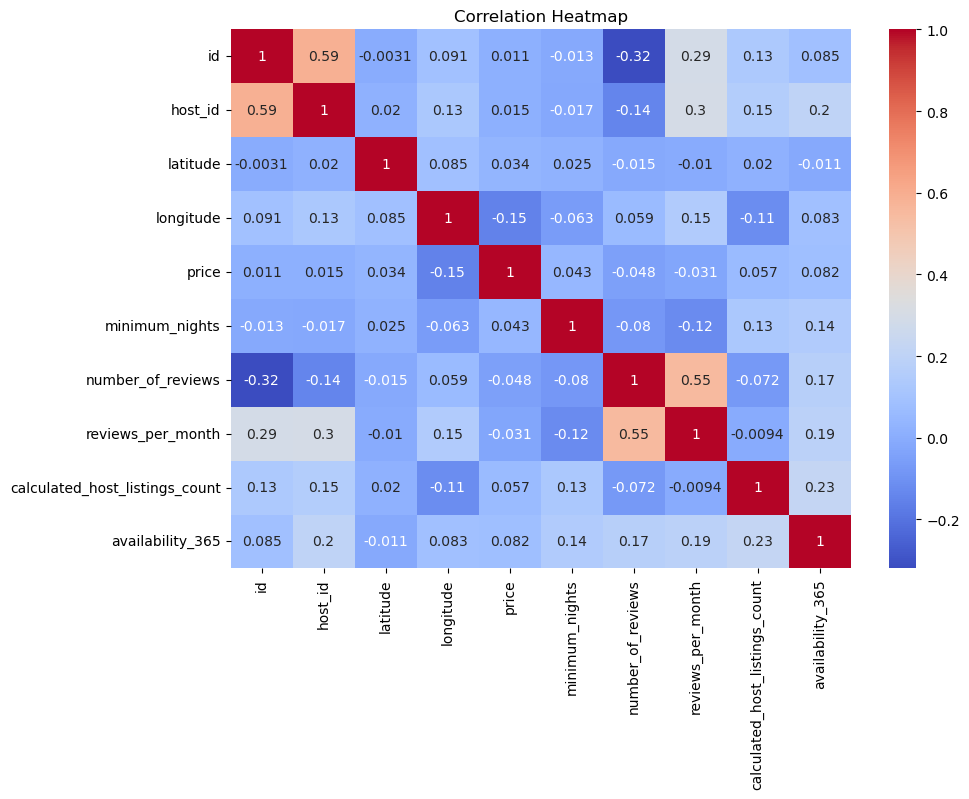

In [8]:
# TASKS BASED ON NEW YORK CITY AIRBNB DATASET (Task 3: Using Data Visualization (Price Distribution, Neighbourhood Comparison, Correlation Heatmap, Scatter Plot)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned dataset
df = pd.read_csv(r"C:\Users\Alana\Downloads\AB_NYC_2019.csv .zip")

# Price Distribution
plt.figure(figsize=(8,5))
sns.histplot(df["price"], bins=40, kde=True)
plt.title("Price Distribution")
plt.show()

# Neighbourhood Comparison
plt.figure(figsize=(8,5))
sns.barplot(data=df,
            x="neighbourhood_group",
            y="price")
plt.xticks(rotation=45)
plt.title("Neighbourhood Comparison")
plt.show()

# Scatter Plot
plt.figure(figsize=(8,5))
sns.scatterplot(data=df,
                x="number_of_reviews",
                y="price",
                hue="room_type")
plt.title("Reviews vs Price")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(10,7))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()